# Travel Time Forecasting for Multi-Origin-Destination Pairs

## Project Overview
This project builds a multiple independent time series forecasting pipeline to predict 15-minute travel times across 182 origin-destination (OD) pairs in Metro Vancouver.  
The goal is to generate **day-ahead traffic forecasts** using historical travel times, temporal features, network-level signals using machine learning.

### Objectives
- Forecast travel time for the next 96 time slots (24 hours)
- Compare model performance against a seasonal naive baseline
- Evaluate whether machine learning improves short-term planning accuracy

### Modeling Approach
- Multi-series recursive forecasting with `skforecast`
- `LightGBMRegressor` as the main forecasting model
- Temporal, cyclical, and rolling-window features
- Backtesting with time-series cross-validation

## 1. Data Loading and Integration

The raw data comes from:
- OD-level travel time records
- Weather observations

The data is merged and aggregated into a 15-minute time series format, where each OD pair is represented as a separate column.

In [3]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt

connection = sqlite3.connect("od_travel_times.db") # Connect to the database

od_names=pd.read_sql("select * from tbl_od_names;", connection) #convert table into Dataframe
od_travel = pd.read_sql("SELECT * FROM tbl_od_travel_times;", connection) #convert table into Dataframe
weather = pd.read_sql("SELECT * FROM tbl_weather_Oct2018;", connection) #convert table into Dataframe

connection.close()

# unique od_pairs
unique_od_pairs = od_names[['od_id','o_name', 'd_name']].drop_duplicates()
od_pairs=od_travel[['od_id','origin','destination']].drop_duplicates()
od_map = unique_od_pairs.merge(od_pairs, on='od_id', how='inner')
od_map[['o_lat', 'o_lon']] = od_map['origin'].str.split(',', expand=True).astype(float)
od_map[['d_lat', 'd_lon']] = od_map['destination'].str.split(',', expand=True).astype(float)

## 2. Metro Vancouver Districts Overview

The forecasting problem is defined over 14 aggregated origin and destination regions across Metro Vancouver and nearby surrounding areas.  
These zones represent the main travel markets used in the dataset, such as Downtown, Richmond, Surrey, Coquitlam, Langley, and Tsawwassen Ferry.

The map below provides geographic context for the OD forecasting task. Each pin represents the approximate location associated with where traffic data is recorded for each region.
Rather than modeling travel at the individual road-segment level, this project focuses on predicting travel time between these broader regional demand zones.



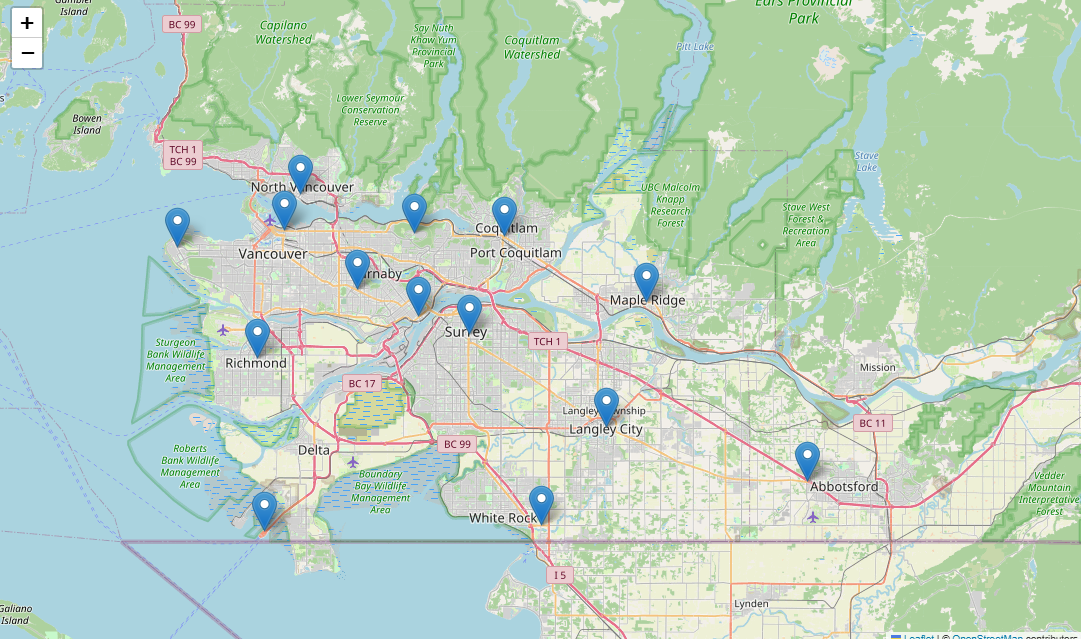

In [48]:
import folium
from IPython.display import Image

origins = od_map[['o_name', 'o_lat', 'o_lon']].rename(
    columns={'o_name': 'region', 'o_lat': 'lat', 'o_lon': 'lon'}
)

destinations = od_map[['d_name', 'd_lat', 'd_lon']].rename(
    columns={'d_name': 'region', 'd_lat': 'lat', 'd_lon': 'lon'}
)

region_centers = pd.concat([origins, destinations], ignore_index=True).drop_duplicates(subset=['region'])

m = folium.Map(location=[49.25, -122.95], zoom_start=10)

for _, row in region_centers.iterrows():
    folium.Marker(
        location=[row['lat'], row['lon']],
        popup=row['region'],
        tooltip=row['region']
    ).add_to(m)

m.save("map.html")

Image("map.png")

### Example Origin–Destination Flows

The following map illustrates a sample of origin–destination (OD) pairs included in the forecasting dataset.  
Each line connects the origin region to the destination region using the representative coordinates associated with that OD pair.
The full dataset contains 182 directed OD pairs, so this subset is shown only for visualization purposes.

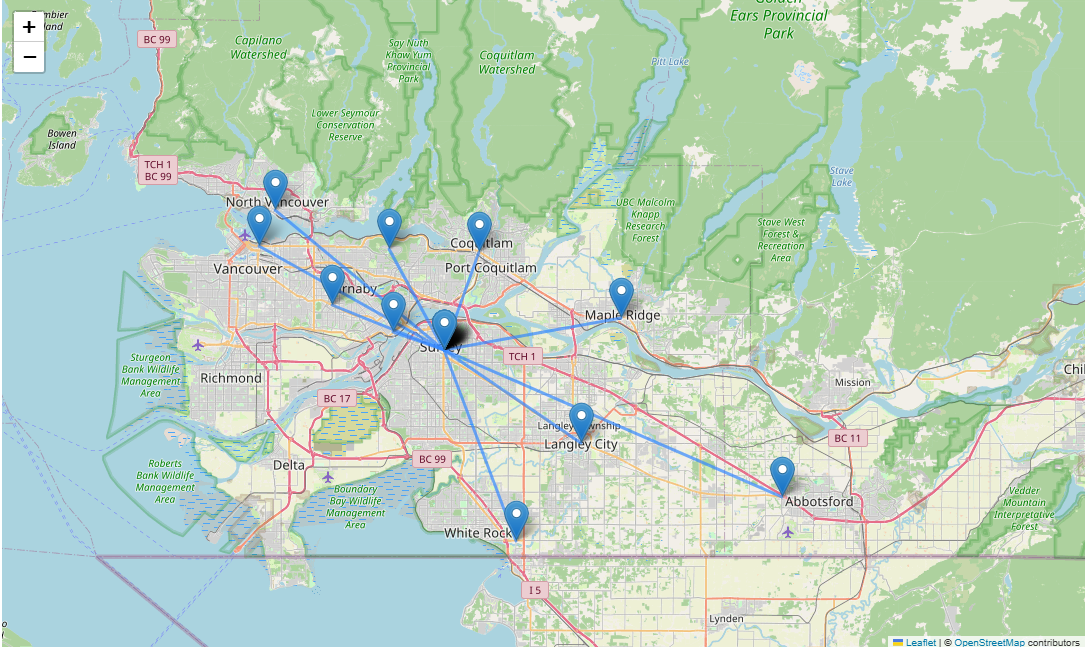

In [56]:
sample_od = od_map.tail(10)

m = folium.Map(location=[49.20, -122.95], zoom_start=10)

for _, row in sample_od.iterrows():
    folium.Marker(
        [row['o_lat'], row['o_lon']],
        tooltip=f"Origin: {row['o_name']}"
    ).add_to(m)
    
    folium.Marker(
        [row['d_lat'], row['d_lon']],
        tooltip=f"Destination: {row['d_name']}"
    ).add_to(m)

    folium.PolyLine(
        locations=[[row['o_lat'], row['o_lon']], [row['d_lat'], row['d_lon']]],
        weight=3,
        opacity=0.7,
        tooltip=f"{row['o_name']} → {row['d_name']}"
    ).add_to(m)

m.save("flow.html")

Image("flow.png")

## 3. Data Preprocessing

This section prepares the dataset for forecasting by:
- converting timestamps to a 15-minute frequency
- handling missing or invalid values
- reshaping the data into a wide multivariate time-series format
- integrating weather information

In [9]:
od_travel['time_stamp'] = pd.to_datetime(od_travel['time_stamp']).dt.floor('15min') #modify data type
od_travel=od_travel[['time_stamp','od_id','origin','destination','distance_m','travel_time_sec']]
od_travel['time_stamp'].asfreq('15Min')

od_travel = od_travel.sort_values('time_stamp')


index_range = pd.date_range(start=od_travel['time_stamp'].min(), end=od_travel['time_stamp'].max(), freq='15min')
missing = index_range.difference(od_travel['time_stamp'])

print(f'total number of missing time_stamps: {len(missing)}')


od_lookup = (od_travel[['od_id', 'origin', 'destination']]
    .drop_duplicates('od_id'))

od_ids = od_travel['od_id'].unique()

df = pd.MultiIndex.from_product( [index_range, od_ids], names=['time_stamp', 'od_id']).to_frame(index=False)

df = df.merge(od_lookup, on='od_id', how='left')

df = df.merge( od_travel[['time_stamp', 'od_id', 'distance_m','travel_time_sec']],on=['time_stamp', 'od_id'], how='left')
df = df.sort_values(['od_id', 'time_stamp'])

df[['distance_m', 'travel_time_sec']] = (df.groupby('od_id')[['distance_m', 'travel_time_sec']].ffill())

df = df.set_index('time_stamp')
df.head()


total number of missing time_stamps: 225


,od_id,origin,destination,distance_m,travel_time_sec
time_stamp,,,,,
2018-10-01 00:00:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1396.0
2018-10-01 00:15:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1412.0
2018-10-01 00:30:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1386.0
2018-10-01 00:45:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1386.0
2018-10-01 01:00:00,1,"49.01127,-123.12652","49.16651,-123.13662",25629.0,1370.0


In [10]:
weather=weather[['Date/Time','Weather']]
weather['time_stamp']=pd.to_datetime(weather['Date/Time'], format='%m/%d/%Y %H:%M')
weather=weather[['time_stamp','Weather']]
weather = weather.set_index('time_stamp').sort_index()
weather =weather.reindex(index_range).ffill()
weather.tail()


,Weather
2018-10-31 22:45:00,"Rain,Drizzle,Fog"
2018-10-31 23:00:00,"Rain,Fog"
2018-10-31 23:15:00,"Rain,Fog"
2018-10-31 23:30:00,"Rain,Fog"
2018-10-31 23:45:00,"Rain,Fog"


In [11]:
# Handling missing values and multiple categories of weather dataset
def categorize_weather(w):
    if w == 'NA':
        return 'Unknown'
    elif w in ['Clear', 'Mainly Clear']:
        return 'Clear'
    elif w in ['Cloudy', 'Mostly Cloudy']:
        return 'Cloudy'
    elif any(x in w for x in ['Rain', 'Drizzle']):
        if 'Moderate' in w:
            return 'Moderate Rain'
        elif 'Heavy' in w or 'Showers' in w:
            return 'Heavy Rain'
        else:
            return 'Light Rain'
    elif 'Fog' in w:
        return 'Fog'
    else:
        return 'Other'

weather['Weather_Category'] = weather['Weather'].apply(categorize_weather)
weather = weather.drop(columns=['Weather'])

In [12]:
# Convert to one column per time series
data = pd.pivot_table(data=df, values="travel_time_sec", index=df.index, columns="od_id")
data.columns.name = None
data.columns = [f"od_{col}" for col in data.columns]

data['weather']=weather['Weather_Category']

c_variable = ['weather'] #one-hot encoding for weather
data = pd.get_dummies(data=data, prefix=c_variable, columns=c_variable)
weather_cols = [c for c in data.columns if c.startswith("weather_")]
data[weather_cols] = data[weather_cols].astype(int)


data.head()


,od_1,od_2,od_3,od_4,od_5,od_6,od_7,od_8,od_9,od_10,...,od_180,od_181,od_182,weather_Clear,weather_Cloudy,weather_Fog,weather_Heavy Rain,weather_Light Rain,weather_Moderate Rain,weather_Unknown
time_stamp,,,,,,,,,,,,,,,,,,,,,
2018-10-01 00:00:00,1396.0,2266.0,2032.0,2545.0,2690.0,1927.0,1749.0,-1.0,2061.0,3025.0,...,1561.0,1402.0,949.0,0,0,0,0,0,0,1
2018-10-01 00:15:00,1412.0,2295.0,2061.0,2577.0,2641.0,1936.0,1703.0,-1.0,2090.0,3002.0,...,1631.0,1418.0,962.0,0,0,0,0,0,0,1
2018-10-01 00:30:00,1386.0,2285.0,2008.0,2573.0,2636.0,1912.0,1708.0,1686.0,2092.0,2998.0,...,1605.0,1428.0,943.0,0,0,0,0,0,0,1
2018-10-01 00:45:00,1386.0,2270.0,1994.0,2562.0,2629.0,1879.0,1700.0,1728.0,2106.0,3014.0,...,1606.0,1421.0,933.0,0,0,0,0,0,0,1
2018-10-01 01:00:00,1370.0,2256.0,1999.0,2510.0,2628.0,1883.0,1700.0,1731.0,2099.0,3020.0,...,1586.0,1319.0,928.0,0,0,0,0,1,0,0


## 4. Feature Engineering

To improve forecasting performance, I created several groups of features:

### Temporal features
- day of week
- hour of day
- weekend indicator
- morning and evening peak indicators

### Cyclical features
Hour and weekday were transformed into sine/cosine representations to preserve their cyclical nature.

### Interaction features
Interaction terms were added to capture effects such as:
- weekday-specific hourly traffic patterns
- weekend peak behavior

### Network-level features
The average network travel time was used to derive features that capture broader congestion conditions across all OD pairs.

### Rolling Window Features

Rolling statistics were added to summarize recent traffic behavior over different time horizons.

These features help capture:
- short-term traffic trends
- medium-term traffic buildup
- daily traffic variability

In [14]:
#exogneous variables
data = data.sort_index()
data = data.asfreq("15min")
data = data.replace(-1, np.nan).ffill().bfill()
data_exog = data.copy()

#Temporal features
target_cols = data_exog.filter(like="od_").columns
data_exog['day_week']=data_exog.index.weekday
data_exog['hour']=data_exog.index.hour
data_exog["slot_in_day"] = data_exog.index.hour * 4 + data_exog.index.minute // 15
data_exog["slot_sin"] = np.sin(2*np.pi*data_exog["slot_in_day"]/96)
data_exog["slot_cos"] = np.cos(2*np.pi*data_exog["slot_in_day"]/96)

data_exog['is_weekend'] = (data_exog.index.weekday >= 5).astype(int)
data_exog["is_monday"] = (data_exog.index.weekday == 0).astype(int)
data_exog["is_friday"] = (data_exog.index.weekday == 4).astype(int)


# Peak indicators
data_exog["is_morning_peak"] = ((data_exog.index.hour >= 7) &  (data_exog.index.hour <= 9)).astype(int)
data_exog["is_evening_peak"] = ((data_exog.index.hour >= 15) &  (data_exog.index.hour <= 17)).astype(int)
data_exog["is_pre_morning_peak"] = ((data_exog.index.hour >= 6) & (data_exog.index.hour < 7)).astype(int)
data_exog["is_post_morning_peak"] = ( (data_exog.index.hour > 9) & (data_exog.index.hour <= 10)).astype(int)

# Weekend interactions
data_exog["morning_x_weekend"] = (data_exog["is_morning_peak"] * data_exog["is_weekend"])
data_exog["evening_x_weekend"] = (data_exog["is_evening_peak"] * data_exog["is_weekend"])

# Network-level temporal features
network_mean = data_exog[target_cols].mean(axis=1).shift(1)

data_exog["network_diff_1d"] = network_mean - network_mean.shift(95)
data_exog["network_diff_1w"] = network_mean - network_mean.shift(671)

data_exog = data_exog.dropna()
data_exog.head()

,od_1,od_2,od_3,od_4,od_5,od_6,od_7,od_8,od_9,od_10,...,is_monday,is_friday,is_morning_peak,is_evening_peak,is_pre_morning_peak,is_post_morning_peak,morning_x_weekend,evening_x_weekend,network_diff_1d,network_diff_1w
time_stamp,,,,,,,,,,,,,,,,,,,,,
2018-10-08 00:00:00,1401.0,2284.0,2050.0,2577.0,2676.0,1934.0,1682.0,1703.0,2104.0,3023.0,...,1,0,0,0,0,0,0,0,16.730769,34.236264
2018-10-08 00:15:00,1400.0,2298.0,2034.0,2575.0,2632.0,1891.0,1675.0,1723.0,2089.0,3001.0,...,1,0,0,0,0,0,0,0,24.175824,11.923077
2018-10-08 00:30:00,1383.0,2291.0,2012.0,2549.0,2619.0,1889.0,1680.0,1739.0,2118.0,2992.0,...,1,0,0,0,0,0,0,0,26.197802,9.120879
2018-10-08 00:45:00,1382.0,2264.0,2009.0,2561.0,2609.0,1883.0,1689.0,1731.0,2087.0,2993.0,...,1,0,0,0,0,0,0,0,28.368132,1.379121
2018-10-08 01:00:00,1372.0,2247.0,2037.0,2496.0,2595.0,1865.0,1675.0,1727.0,2081.0,3001.0,...,1,0,0,0,0,0,0,0,31.620879,1.532967


In [15]:
from feature_engine.creation import CyclicalFeatures

trafo = CyclicalFeatures(variables=["day_week", "hour"]) #to help the linear models to better capture the hourly and weekly seasonality of data, we use both the hour, and cyclical features of thses variables to the model
data_exog = trafo.fit_transform(data_exog)

#day_hour interaction
data_exog["hour_day_interact_1"] = data_exog["hour_sin"] * data_exog["day_week_sin"]
data_exog["hour_day_interact_2"] = data_exog["hour_sin"] * data_exog["day_week_cos"]
data_exog["hour_day_interact_3"] = data_exog["hour_cos"] * data_exog["day_week_sin"]
data_exog["hour_day_interact_4"] = data_exog["hour_cos"] * data_exog["day_week_cos"]

In [16]:
from skforecast.preprocessing import RollingFeatures

window_features = RollingFeatures(
    stats=["mean","mean","mean","mean","mean","mean","std","std","std","std","std","std"],
    window_sizes=[4,8,24,48,96,192,4,8,24,48,96,192 ] 
)

window_features

RollingFeatures(
    stats           = ['mean', 'mean', 'mean', 'mean', 'mean', 'mean', 'std', 'std', 'std', 'std', 'std', 'std'],
    window_sizes    = [4, 8, 24, 48, 96, 192, 4, 8, 24, 48, 96, 192],
    Max window size = 192,
    min_periods     = [4, 8, 24, 48, 96, 192, 4, 8, 24, 48, 96, 192],
    features_names  = ['roll_mean_4', 'roll_mean_8', 'roll_mean_24', 'roll_mean_48', 'roll_mean_96', 'roll_mean_192', 'roll_std_4', 'roll_std_8', 'roll_std_24', 'roll_std_48', 'roll_std_96', 'roll_std_192'],
    fillna          = None
    kwargs_stats    = {'ewm': {'alpha': 0.3}},
)

## 5. Forecasting Model

I used a **recursive multi-series forecasting approach** in **Skforecast**, with **LightGBM** as the base regressor.

### Why this approach?
- It allows all OD pairs to be modeled jointly
- It captures shared traffic dynamics across the network
- It supports exogenous variables and rolling features

In [18]:
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor

from skforecast.recursive import ForecasterRecursiveMultiSeries


# Target time series column names
target_cols = data_exog.filter(like="od_").columns

# Exogenous feature column names
exog_cols = data_exog.columns.drop(target_cols)

exog_cols


Index(['weather_Clear', 'weather_Cloudy', 'weather_Fog', 'weather_Heavy Rain',
       'weather_Light Rain', 'weather_Moderate Rain', 'weather_Unknown',
       'day_week', 'hour', 'slot_in_day', 'slot_sin', 'slot_cos', 'is_weekend',
       'is_monday', 'is_friday', 'is_morning_peak', 'is_evening_peak',
       'is_pre_morning_peak', 'is_post_morning_peak', 'morning_x_weekend',
       'evening_x_weekend', 'network_diff_1d', 'network_diff_1w',
       'day_week_sin', 'day_week_cos', 'hour_sin', 'hour_cos',
       'hour_day_interact_1', 'hour_day_interact_2', 'hour_day_interact_3',
       'hour_day_interact_4'],
      dtype='object')

In [19]:
from skforecast.model_selection import backtesting_forecaster_multiseries, TimeSeriesFold


## 6. Backtesting Strategy

To evaluate the model in a realistic forecasting setting, I used time-series backtesting with:

- **Forecast horizon:** 96 steps (1 day ahead)
- **Cross-validation strategy:** rolling/expanding time-based folds
- **Metric:** Mean Absolute Error (MAE)

This setup simulates how the model would perform in real operational use.

In [21]:
from skforecast.model_selection import random_search_forecaster_multiseries
import lightgbm as lgb


param_lgbm ={'n_estimators': 2000, 'max_depth': 5, 'learning_rate': 0.1}
 
# regressor
forecaster_lgbm = ForecasterRecursiveMultiSeries(
    estimator=LGBMRegressor(**param_lgbm,random_state=8520, verbose=-1),
    lags = [1,2,3,4,6,8,12,16,24,48,
            92,93,94,95,96,97,98,99,100,192,288,
            668,669,670,671,672,673,674,675,676],
    window_features=window_features,
    transformer_series=StandardScaler(),
    transformer_exog=StandardScaler()
)

steps = 96 #validation size

initial_train_size = len(data_exog) - steps * 7

# how time series is split during backtesting
cv = TimeSeriesFold(
    steps                 = steps,
    initial_train_size    = initial_train_size,
    skip_folds            = None,
    refit                 = True,
    fixed_train_size=False,
    allow_incomplete_fold = True,
)


#  backtesting
metric, predictions = backtesting_forecaster_multiseries(
    forecaster=forecaster_lgbm,
    series=data_exog[target_cols],
    exog=data_exog[exog_cols],
    cv=cv,
    metric="mean_absolute_error",
    verbose=True,
    show_progress=True,
)


╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : C:\Users\bahar\anaconda3\Lib\site-packages\skforecast\utils\utils.py:2368 │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

Information of folds
--------------------
Number of observations used for initial training: 1632
Number of observations used for backtesting: 672
    Number of folds: 7
    Number skipped folds: 0 
    Number of steps per fold: 96
    Number of steps to exclude between last observed data (last window) and predictions (gap): 0

Fold: 0
    Training:   2018-10-08 00:00:00 -- 2018-10-24 23:45:00  (n=1632)
    Validation: 2018-10-25 00:00:00 -- 2018-10-25 23:45:00  (n=96)
Fold: 1
    Training:   2018-10-08 00:00:00 -- 2018-10-25 23:45:00  (n=1728)
    Validation: 2018-10-26 00:00:00 -- 2018-10-26 23:45:00  (n=96)
Fold: 2
    Training:   2018-10-08 00:00:00 -- 2018-10-26 23:45:00  (n=1824)
    Validation: 2018-10-27 00:00:00 -- 2018-10-27 23:45:00  (n=96)
Fold: 3
    Training:   2018-10-08 00:00:00 -- 2018-10-27 23:45:00  (n=1920)
    Validation: 2018-10-28 00:00:00 -- 2018-10-28 23:45:00  (n=96)
Fold: 4
    Training:   2018-10-08 00:00:00 -- 2018-10-28 23:45:00  (n=2016)
    Validation: 20

  0%|          | 0/7 [00:00<?, ?it/s]

## 7. Model Performance

The model was evaluated using:
- **MAE**: average absolute prediction error in seconds
- **MAPE**: average percentage error

These metrics were also compared against a **seasonal naive baseline** using the previous day's travel time.

In [23]:
predictions.head()

,level,fold,pred
2018-10-25,od_1,0,1406.841417
2018-10-25,od_2,0,2310.875495
2018-10-25,od_3,0,2109.217433
2018-10-25,od_4,0,2599.689579
2018-10-25,od_5,0,2660.847682


In [24]:
fc = predictions.reset_index()
time_col = fc.columns[0] 
forecast_wide = fc.pivot(
    index=time_col,
    columns='level',
    values='pred'
)

forecast_wide = forecast_wide.reindex(columns=target_cols)


In [25]:
from sklearn.metrics import mean_absolute_error,mean_absolute_percentage_error

y_true=data_exog.loc[forecast_wide.index,target_cols]
y_pred=forecast_wide.loc[forecast_wide.index, target_cols]

mae=mean_absolute_error(y_true,y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)


print("MAE:", mae)
print("MAPE:", mape)

MAE: 65.39643627821809
MAPE: 0.029955594324909365


## 8. Feature importance
To understand the drivers of the model’s predictions, feature importance was extracted from the final LightGBM forecaster trained on the full dataset.

The results show that recent lag features (e.g., **lag_1**, **lag_2**) and weekly patterns (**lag_672**) are the most influential predictors, highlighting strong temporal dependencies in travel time. Engineered features such as **network_diff_1d** and **network_diff_1w** also contribute significantly, while calendar-based variables have minimal impact.

In [27]:
forecaster_lgbm.fit(
    series=data_exog[target_cols],
    exog=data_exog[exog_cols]
)

feature_importance=forecaster_lgbm.get_feature_importances()
feature_importance.head()

╭────────────────────────────────── InputTypeWarning ──────────────────────────────────╮
│ Passing a DataFrame (either wide or long format) as `series` requires additional     │
│ internal transformations, which can increase computational time. It is recommended   │
│ to use a dictionary of pandas Series instead. For more details, see:                 │
│ https://skforecast.org/latest/user_guides/independent-multi-time-series-forecasting. │
│ html#input-data                                                                      │
│                                                                                      │
│ Category : skforecast.exceptions.InputTypeWarning                                    │
│ Location : C:\Users\bahar\anaconda3\Lib\site-packages\skforecast\utils\utils.py:2368 │
│ Suppress : warnings.simplefilter('ignore', category=InputTypeWarning)                │
╰──────────────────────────────────────────────────────────────────────────────────────╯

,feature,importance
0,lag_1,2802
64,network_diff_1d,1702
65,network_diff_1w,1647
1,lag_2,1435
25,lag_672,1383


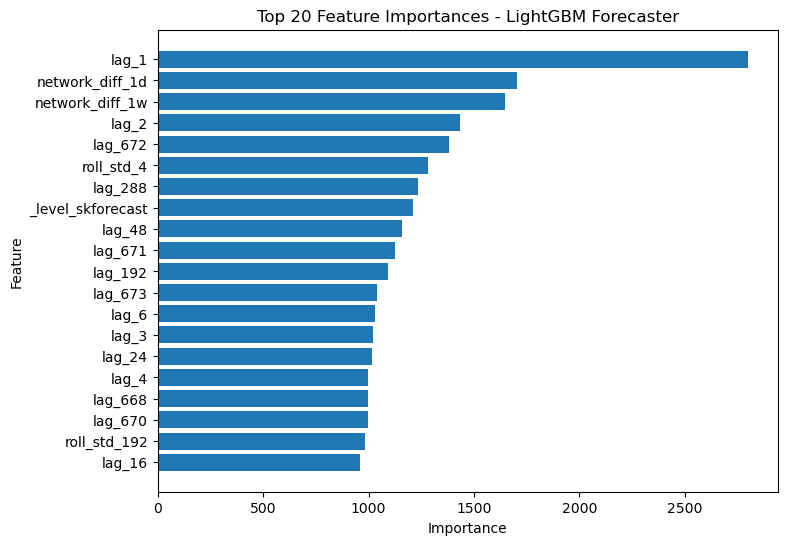

In [28]:
top_n = 20
fi_top = feature_importance.head(top_n).sort_values('importance')

plt.figure(figsize=(8, 6))
plt.barh(fi_top['feature'], fi_top['importance'])
plt.title('Top 20 Feature Importances - LightGBM Forecaster')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## 9. Baseline Comparison

To assess whether the machine learning model adds value, I compared it against a **seasonal naive baseline**:

$$
\hat{y}_t = y_{t-96}
$$

This baseline assumes that travel time at a given 15-minute interval will be similar to the same interval on the previous day.

In [30]:
# MAE of baseline

baseline_yday = data_exog[target_cols].shift(96).loc[forecast_wide.index]
y_true=data_exog.loc[forecast_wide.index,target_cols]


mae_baseline=mean_absolute_error(y_true,baseline_yday)
mape_baseline = mean_absolute_percentage_error(y_true, baseline_yday)

print("MAE:", mae_baseline)
print("MAPE:", mape_baseline)

MAE: 117.47560177917322
MAPE: 0.053508854073606976


In [31]:
improvement = (mae_baseline - mae) / mae_baseline * 100
print(f"Improvement over baseline: {improvement:.1f}%")

Improvement over baseline: 44.3%


## 10. Forecast vs Actual Travel Time

The following plots compare actual travel time against predictions from both the LightGBM forecaster and a seasonal naive baseline for a sample of OD pairs.

These visualizations help assess:
- how well each approach captures daily traffic patterns,
- whether the LightGBM model better tracks morning and evening peaks,
- and where the machine learning model improves over a simple baseline.

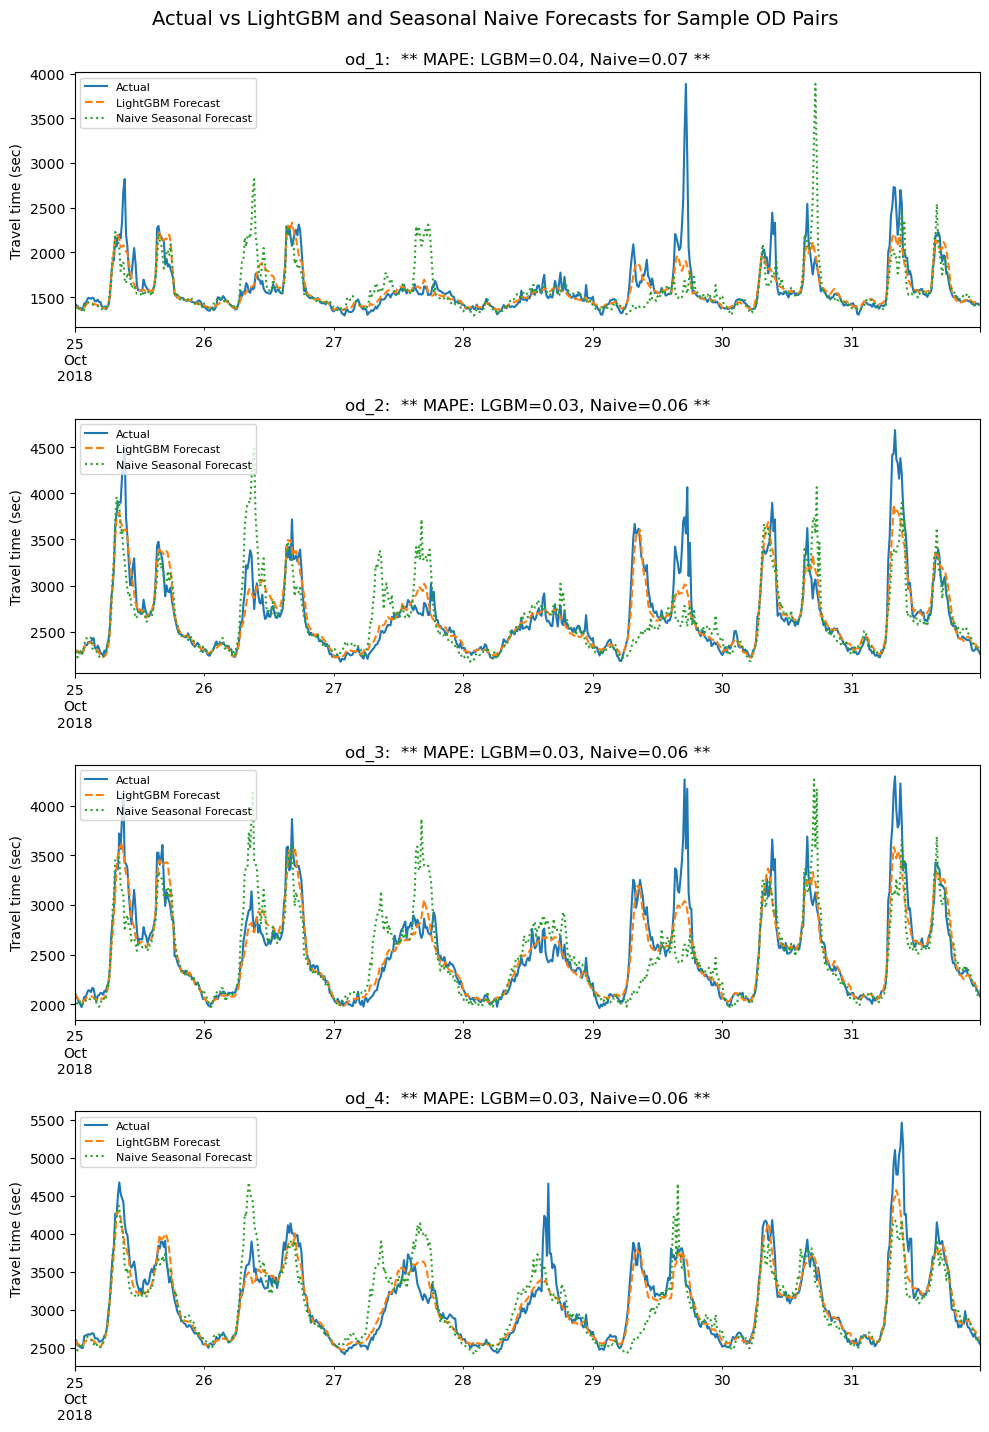

In [36]:
actual = data_exog.loc[forecast_wide.index, target_cols]
num_timeseries = 4
fig, axs = plt.subplots(nrows=num_timeseries, figsize=(10, 3.5*num_timeseries))

for i in range(num_timeseries):
    
    ts = target_cols[i]

    actual_ts = actual[ts]
    lgbm_ts = forecast_wide[ts]
    naive_ts = baseline_yday[ts]

    mae_lgbm = mean_absolute_percentage_error(actual_ts, lgbm_ts)
    mae_naive = mean_absolute_percentage_error(actual_ts, naive_ts)

    actual_ts.plot(ax=axs[i], label="Actual", legend=True)
    lgbm_ts.plot(ax=axs[i], label="LightGBM Forecast", linestyle="--", legend=True)
    naive_ts.plot(ax=axs[i], label="Naive Seasonal Forecast", linestyle=":", legend=True)

    axs[i].set_title(f"{ts}:  ** MAPE: LGBM={mae_lgbm:.2f}, Naive={mae_naive:.2f} **")
    axs[i].set_xlabel("")
    axs[i].set_ylabel("Travel time (sec)")
    axs[i].legend(loc="upper left")
    axs[i].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.suptitle(
    "Actual vs LightGBM and Seasonal Naive Forecasts for Sample OD Pairs",
    fontsize=14,
    y=1.02
)
plt.show()

## 11. Conclusion

This project developed a day-ahead travel time forecasting model for 182 OD pairs using a recursive multi-series machine learning approach.

### Key takeaways
- Strong temporal dependencies were observed, with recent lag features and weekly patterns being the most important predictors.
- Engineered features capturing short-term and weekly network changes significantly improved model performance.
- The LightGBM-based forecasting model outperformed the seasonal naive baseline
- Prediction accuracy was strongest during normal traffic periods and weaker around peak congestion hours.

### Future Improvements
- incorporate spatial neighbor features between OD pairs
- test direct forecasting to reduce recursive error accumulation
- include richer external signals such as incidents or holiday effects